# Exploratory Data Analysis (EDA)
This notebook performs comprehensive exploratory data analysis on the cleaned pain medication data, including visualizations and insights.

## 1. Import Required Libraries

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Load Cleaned Data

In [2]:
# TODO: Load cleaned data
cleaned_data_path = '../data/cleaned/pain_meds_cleaned.csv'

df = pd.read_csv(cleaned_data_path)

print(f"Cleaned data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
display(df.head())

Cleaned data loaded successfully!
Shape: (2473, 8)

First few rows:


,uniqueID,drugName,condition,review,rating,date,usefulCount,year
0,189138,Oxycodone,chronic pain,"""I&#039;ve been taking oxycodone for roughly 5 years....I&#039;ve gone a few weekends without it...",8,18-Dec-16,24,2016
1,80410,Aleve,back pain,"""I love Aleve! It makes all my lower back pain disappear, I feel like a new person.""",10,12-Aug-10,41,2010
2,171980,Meloxicam,osteoarthritis,"""I have been using Mobic to relieve the pain from my Spinal Fusion I had in March/2001. I was pr...",10,25-Sep-09,26,2009
3,40937,Acetaminophen / oxycodone,chronic pain,"""This med helps to take the edge off enough for the pain to be tolerable. I take HCL 15 mg one e...",6,10-Nov-17,0,2017
4,113576,Acetaminophen / butalbital / caffeine,headache,"""I have been suffering from terrible allergies due to hay fever. The allergies caused horrible ...",9,19-Sep-11,0,2011


## 3. Summary Statistics

In [3]:
# TODO: Display summary statistics
print("Dataset Overview:")
print("=" * 60)
df.info()

print("\nStatistical Summary:")
print("=" * 60)
display(df.describe())

# Value counts for categorical columns
print("\nTop 10 Conditions:")
print(df['condition'].value_counts().head(10))

print("\nTop 10 Drugs:")
print(df['drugName'].value_counts().head(10))

if 'rating' in df.columns:
    print("\nRating Distribution:")
    print(df['rating'].value_counts().sort_index())

Dataset Overview:
<class 'pandas.DataFrame'>
RangeIndex: 2473 entries, 0 to 2472
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   uniqueID     2473 non-null   int64
 1   drugName     2473 non-null   str  
 2   condition    2473 non-null   str  
 3   review       2473 non-null   str  
 4   rating       2473 non-null   int64
 5   date         2473 non-null   str  
 6   usefulCount  2473 non-null   int64
 7   year         2473 non-null   int64
dtypes: int64(4), str(4)
memory usage: 154.7 KB

Statistical Summary:


,uniqueID,rating,usefulCount,year
count,2473.000000,2473.000000,2473.000000,2473.000000
mean,122743.448443,7.771533,29.812778,2013.419733
std,59442.263626,2.951325,28.780221,2.728425
min,2850.000000,1.000000,0.000000,2008.000000
25%,71775.000000,7.000000,10.000000,2011.000000
50%,113610.000000,9.000000,22.000000,2014.000000
75%,171963.000000,10.000000,41.000000,2016.000000
max,230411.000000,10.000000,216.000000,2017.000000



Top 10 Conditions:
condition
back pain                        523
chronic pain                     518
osteoarthritis                   416
headache                         403
migraine                         282
rheumatoid arthritis             167
sciatica                          76
muscle pain                       64
juvenile rheumatoid arthritis      9
cluster headaches                  8
Name: count, dtype: int64

Top 10 Drugs:
drugName
Diclofenac                               290
Tramadol                                 288
Oxycodone                                245
Naproxen                                 207
Acetaminophen / hydrocodone              205
Acetaminophen / butalbital / caffeine    176
Meloxicam                                152
Acetaminophen / oxycodone                140
Acetaminophen / aspirin / caffeine       105
Naproxen / sumatriptan                    89
Name: count, dtype: int64

Rating Distribution:
rating
1     243
2      63
3      50
4      54
5    

## 4. Histogram of Ratings

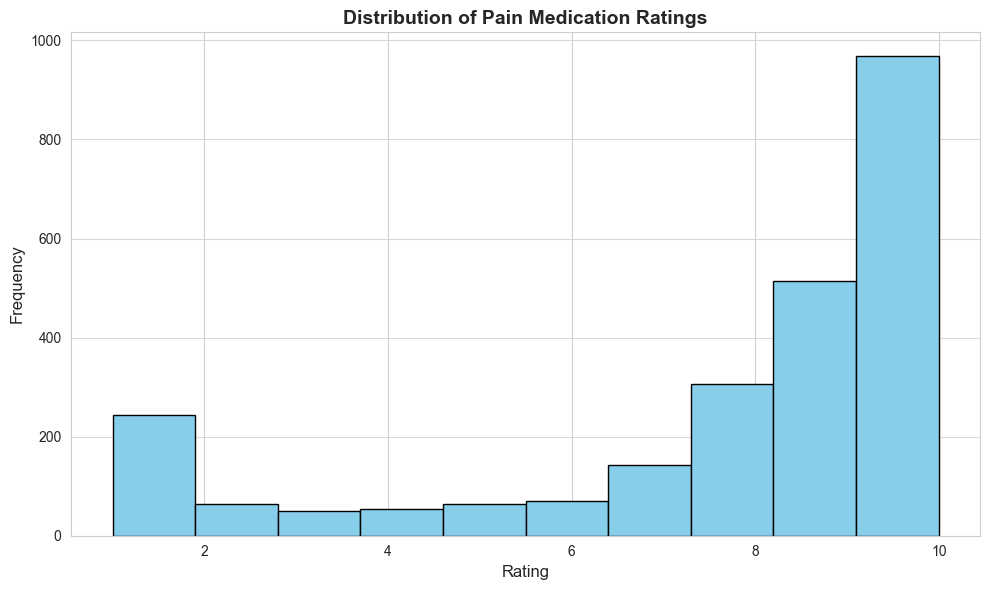

Mean Rating: 7.77
Median Rating: 9.00
Mode Rating: 10
Standard Deviation: 2.95


In [4]:
# TODO: Create histogram of rating distribution
if 'rating' in df.columns:
    plt.figure(figsize=(10, 6))
    plt.hist(df['rating'], bins=10, edgecolor='black', color='skyblue')
    plt.xlabel('Rating', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Distribution of Pain Medication Ratings', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()
    
    # Display statistics
    print(f"Mean Rating: {df['rating'].mean():.2f}")
    print(f"Median Rating: {df['rating'].median():.2f}")
    print(f"Mode Rating: {df['rating'].mode()[0]}")
    print(f"Standard Deviation: {df['rating'].std():.2f}")

## 5. Bar Charts for Top Conditions and Drugs

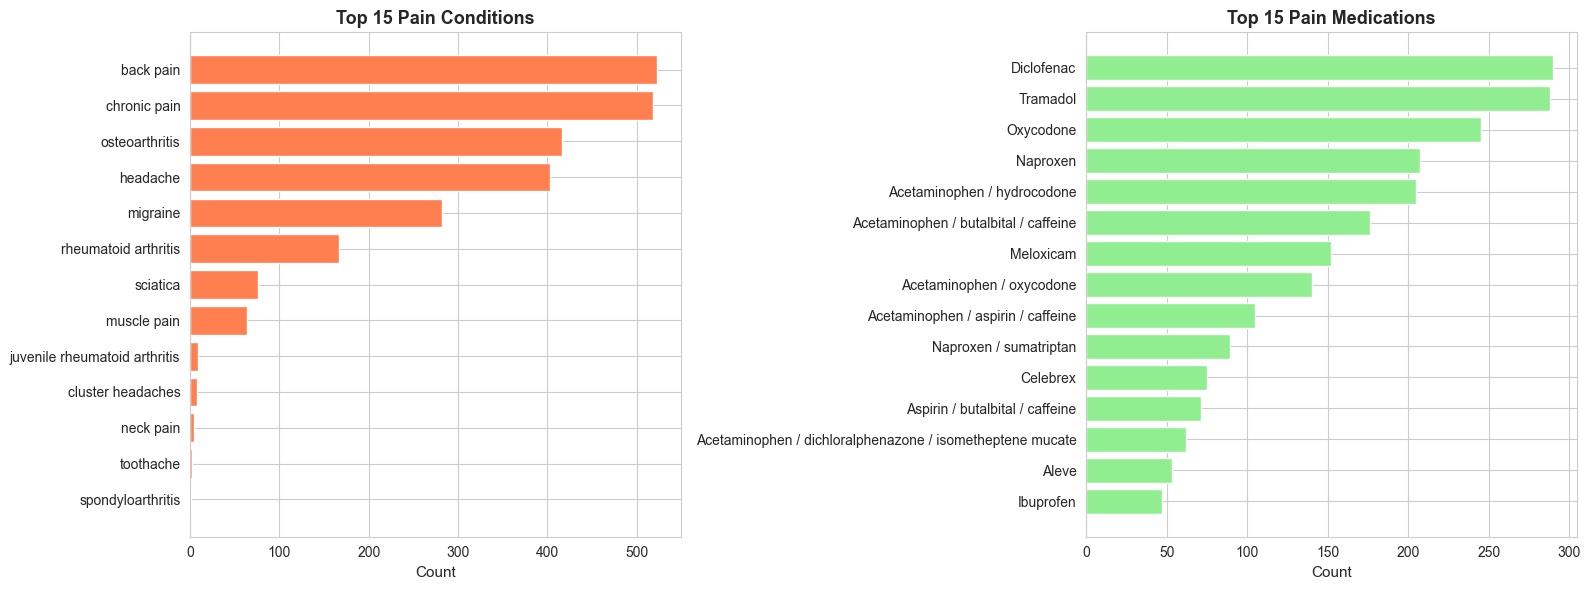

In [5]:
# TODO: Create bar charts for top conditions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 conditions
top_conditions = df['condition'].value_counts().head(15)
axes[0].barh(range(len(top_conditions)), top_conditions.values, color='coral')
axes[0].set_yticks(range(len(top_conditions)))
axes[0].set_yticklabels(top_conditions.index)
axes[0].set_xlabel('Count', fontsize=11)
axes[0].set_title('Top 15 Pain Conditions', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

# Top 15 drugs
top_drugs = df['drugName'].value_counts().head(15)
axes[1].barh(range(len(top_drugs)), top_drugs.values, color='lightgreen')
axes[1].set_yticks(range(len(top_drugs)))
axes[1].set_yticklabels(top_drugs.index)
axes[1].set_xlabel('Count', fontsize=11)
axes[1].set_title('Top 15 Pain Medications', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 6. Boxplot of Rating by Condition

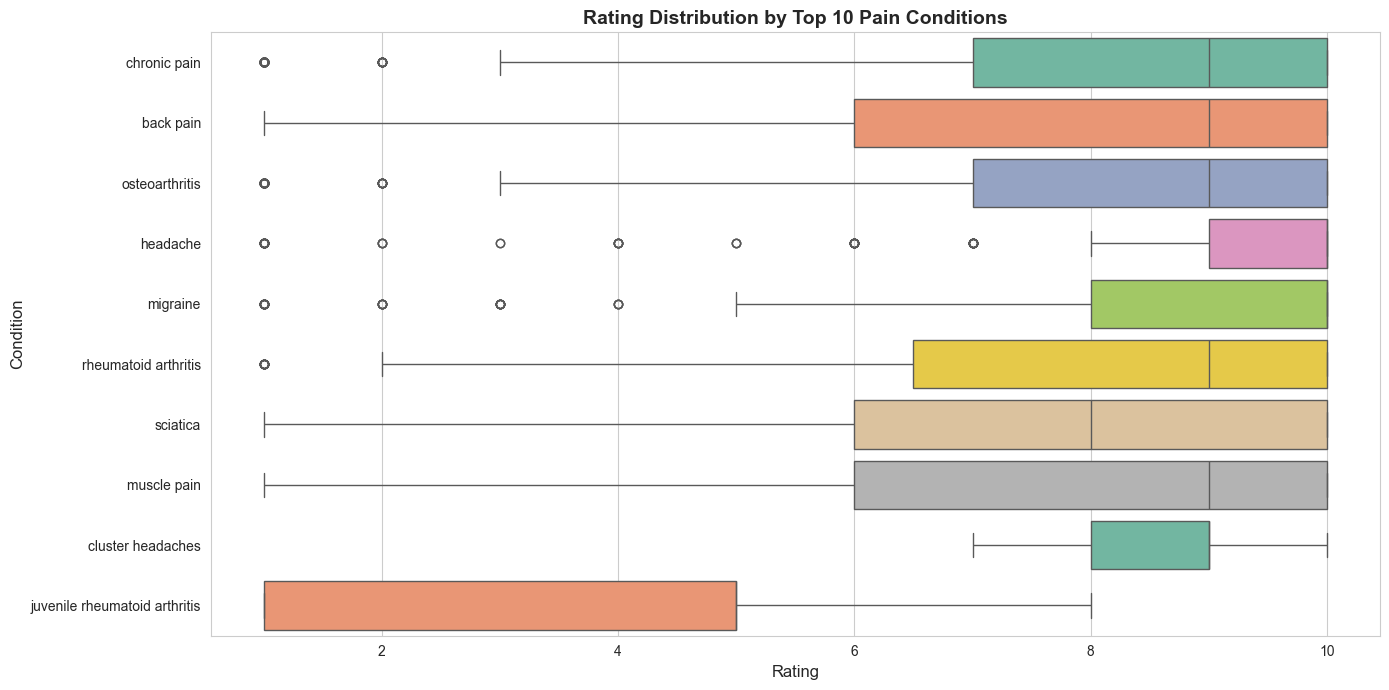


Mean Rating by Top 10 Conditions:


condition
headache                         8.736973
cluster headaches                8.625000
migraine                         8.294326
osteoarthritis                   7.778846
rheumatoid arthritis             7.491018
chronic pain                     7.463320
muscle pain                      7.375000
back pain                        7.372849
sciatica                         7.105263
juvenile rheumatoid arthritis    4.111111
Name: rating, dtype: float64

In [6]:
# TODO: Create boxplot of ratings by top conditions
if 'rating' in df.columns:
    # Get top 10 conditions
    top_10_conditions = df['condition'].value_counts().head(10).index
    df_top_conditions = df[df['condition'].isin(top_10_conditions)]
    
    plt.figure(figsize=(14, 7))
    sns.boxplot(data=df_top_conditions, y='condition', x='rating', palette='Set2')
    plt.xlabel('Rating', fontsize=12)
    plt.ylabel('Condition', fontsize=12)
    plt.title('Rating Distribution by Top 10 Pain Conditions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Calculate mean rating by condition
    print("\nMean Rating by Top 10 Conditions:")
    mean_ratings = df_top_conditions.groupby('condition')['rating'].mean().sort_values(ascending=False)
    display(mean_ratings)

## 7. Boxplot of Rating by Drug

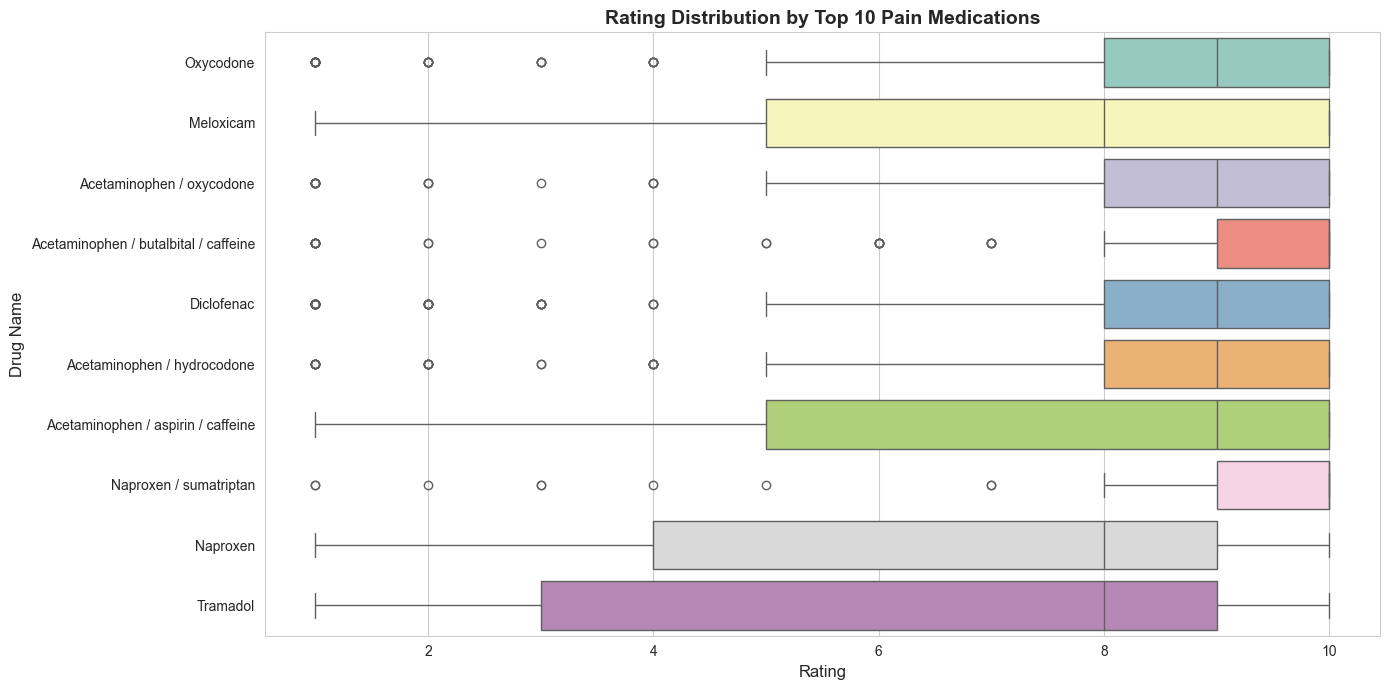


Mean Rating by Top 10 Drugs:


drugName
Naproxen / sumatriptan                   8.988764
Acetaminophen / butalbital / caffeine    8.767045
Acetaminophen / hydrocodone              8.151220
Diclofenac                               8.010345
Acetaminophen / oxycodone                7.985714
Oxycodone                                7.959184
Acetaminophen / aspirin / caffeine       7.504762
Meloxicam                                7.072368
Naproxen                                 6.705314
Tramadol                                 6.534722
Name: rating, dtype: float64

In [7]:
# TODO: Create boxplot of ratings by top drugs
if 'rating' in df.columns:
    # Get top 10 drugs
    top_10_drugs = df['drugName'].value_counts().head(10).index
    df_top_drugs = df[df['drugName'].isin(top_10_drugs)]
    
    plt.figure(figsize=(14, 7))
    sns.boxplot(data=df_top_drugs, y='drugName', x='rating', palette='Set3')
    plt.xlabel('Rating', fontsize=12)
    plt.ylabel('Drug Name', fontsize=12)
    plt.title('Rating Distribution by Top 10 Pain Medications', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Calculate mean rating by drug
    print("\nMean Rating by Top 10 Drugs:")
    mean_drug_ratings = df_top_drugs.groupby('drugName')['rating'].mean().sort_values(ascending=False)
    display(mean_drug_ratings)

## 8. Correlation Heatmap

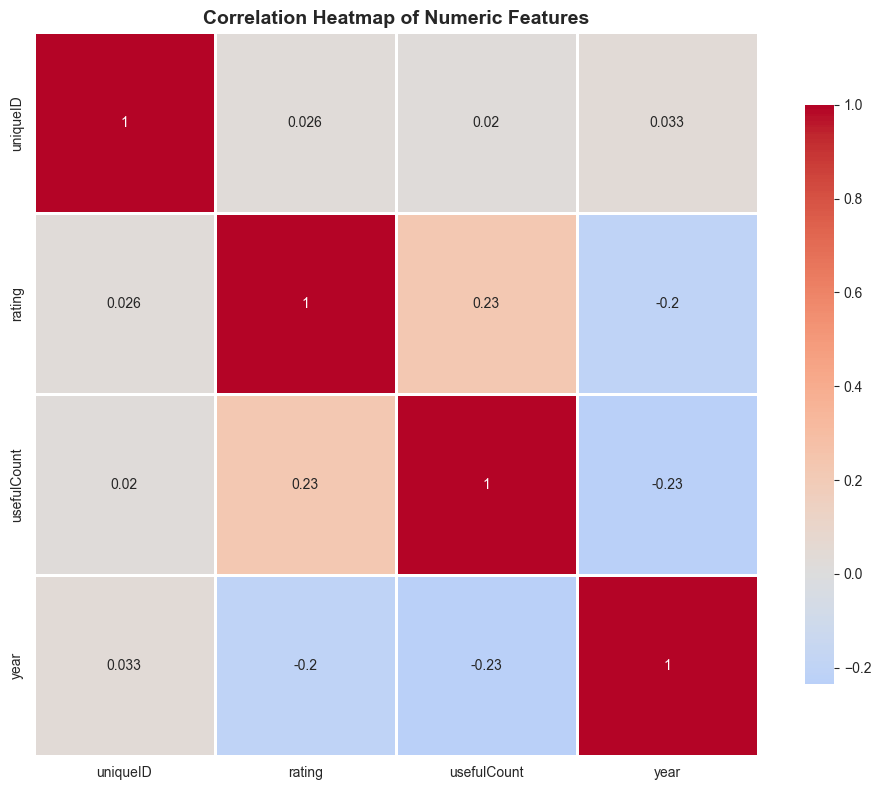

In [8]:
# TODO: Create correlation heatmap for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns

if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 8))
    correlation_matrix = df[numeric_cols].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation analysis.")
    print(f"Numeric columns: {list(numeric_cols)}")

## 9. Key Insights and Observations

### TODO: Document key insights from the exploratory analysis

**Observations:**

1. **Rating Distribution:**
   - [Describe the overall pattern of ratings - are they skewed towards high or low ratings?]
   - [Note any unusual patterns or gaps in the distribution]

2. **Top Conditions:**
   - [List the most common pain conditions in the dataset]
   - [Note if certain conditions have significantly more reviews than others]

3. **Top Medications:**
   - [List the most frequently reviewed pain medications]
   - [Compare generic vs brand names if applicable]

4. **Rating by Condition:**
   - [Which conditions tend to have higher/lower ratings?]
   - [Note any conditions with high variability in ratings]

5. **Rating by Drug:**
   - [Which medications tend to receive higher/lower ratings?]
   - [Note any drugs with particularly consistent or inconsistent ratings]

6. **Correlations:**
   - [Describe any significant correlations found between numeric features]
   - [Note any unexpected relationships]

7. **Data Quality:**
   - [Comment on the overall quality and completeness of the data]
   - [Note any limitations or biases observed]

**Implications for Modeling:**
- [How might these insights affect feature engineering and model selection?]
- [Are there any preprocessing steps needed based on these observations?]
- [Should certain features be given more weight or attention?]